# **WEEK 4**

# *Task 1: ML Pipeline & Feature Engineering*

# Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

# Step 2 — Load the Titanic Dataset

In [2]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Step 3 — Understand the Dataset

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (891, 12)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Step 4 — Feature Engineering

## Feature Engineering

Two new features will be created:

1. **FamilySize** = SibSp + Parch + 1
   - Represents the total number of people in the passenger's family group.

2. **IsAlone**
   - 1 if the passenger was traveling alone.
   - 0 if the passenger was traveling with family.

In [7]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df[["SibSp", "Parch", "FamilySize", "IsAlone"]].head(10)

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


# Step 5 — Select Features

In [9]:
features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "Sex",
    "Embarked"
]

X = df[features]
y = df["Survived"]

In [10]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex,Embarked
0,3,22.0,1,0,7.2500,2,0,male,S
1,1,38.0,1,0,71.2833,2,0,female,C
2,3,26.0,0,0,7.9250,1,1,female,S
3,1,35.0,1,0,53.1000,2,0,female,S
4,3,35.0,0,0,8.0500,1,1,male,S


# Step 6 — Split the Data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 9)
Testing data: (179, 9)


# Step 7 — Identify Numerical and Categorical Columns

In [13]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

categorical_features = [
    "Sex",
    "Embarked"
]

# Step 8 — Build Numerical Preprocessing

In [14]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Step 9 — Build Categorical Preprocessing

In [15]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

# Step 10 — Create the ColumnTransformer

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Step 11 — Create the ML Pipeline

In [17]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

# Step 12 — Train the Pipeline

In [18]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize', 'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model', LogisticRegression(max_iter=1000))])

#Step 13 — Make Predictions

In [19]:
y_pred = pipeline.predict(X_test)

# Step 14 — Evaluate the Pipeline

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Pipeline Accuracy:", accuracy)

Pipeline Accuracy: 0.8044692737430168


In [21]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7833333333333333
Recall: 0.6811594202898551
F1 Score: 0.7286821705426356


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



# Step 15 — Confusion Matrix

In [23]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[97 13]
 [22 47]]


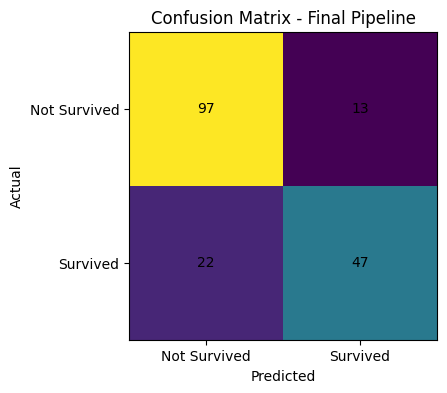

In [24]:
plt.figure(figsize=(6, 4))

plt.imshow(cm)

plt.title("Confusion Matrix - Final Pipeline")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.yticks([0, 1], ["Not Survived", "Survived"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

# Step 16 — Test Whether Feature Engineering Improved Performance

In [25]:
baseline_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Sex",
    "Embarked"
]

X_baseline = df[baseline_features]
y_baseline = df["Survived"]

In [26]:
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline,
    y_baseline,
    test_size=0.2,
    random_state=42,
    stratify=y_baseline
)

# Step 17 — Build Baseline Pipeline

In [27]:
baseline_numeric = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

baseline_categorical = [
    "Sex",
    "Embarked"
]

In [28]:
baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            baseline_numeric
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        drop="first"
                    )
                )
            ]),
            baseline_categorical
        )
    ]
)

In [29]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", baseline_preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [30]:
baseline_pipeline.fit(X_train_base, y_train_base)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [31]:
y_pred_base = baseline_pipeline.predict(X_test_base)

In [32]:
baseline_accuracy = accuracy_score(
    y_test_base,
    y_pred_base
)

baseline_precision = precision_score(
    y_test_base,
    y_pred_base
)

baseline_recall = recall_score(
    y_test_base,
    y_pred_base
)

baseline_f1 = f1_score(
    y_test_base,
    y_pred_base
)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall:", baseline_recall)
print("Baseline F1:", baseline_f1)

Baseline Accuracy: 0.8044692737430168
Baseline Precision: 0.7931034482758621
Baseline Recall: 0.6666666666666666
Baseline F1: 0.7244094488188977


# Step 18 — Compare Baseline vs Feature Engineering

In [33]:
final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred)
final_recall = recall_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)

In [34]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "With Feature Engineering": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

comparison

,Metric,Baseline,With Feature Engineering
0,Accuracy,0.804469,0.804469
1,Precision,0.793103,0.783333
2,Recall,0.666667,0.681159
3,F1 Score,0.724409,0.728682


# Step 19 — Calculate Improvement

In [35]:
improvement = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Improvement": [
        final_accuracy - baseline_accuracy,
        final_precision - baseline_precision,
        final_recall - baseline_recall,
        final_f1 - baseline_f1
    ]
})

improvement

,Metric,Improvement
0,Accuracy,0.000000
1,Precision,-0.009770
2,Recall,0.014493
3,F1 Score,0.004273


In [36]:
print(
    f"Accuracy improvement: "
    f"{(final_accuracy - baseline_accuracy) * 100:.2f}%"
)

print(
    f"F1 improvement: "
    f"{(final_f1 - baseline_f1) * 100:.2f}%"
)

Accuracy improvement: 0.00%
F1 improvement: 0.43%


# Step 20 — Explaining Pipeline

## Why Use an ML Pipeline?

A Scikit-learn Pipeline combines preprocessing and model training into a
single reusable object.

In this project, the pipeline performs:

1. Missing-value imputation
2. Numerical feature scaling using StandardScaler
3. Categorical feature encoding using OneHotEncoder
4. Logistic Regression training

The main advantage is that preprocessing is learned only from the training
data and then consistently applied to the test data. This helps prevent
data leakage and makes the workflow easier to reproduce and deploy.

# Step 21 — Explaining Feature Engineering

## Feature Engineering Results

Two engineered features were created:

### FamilySize

FamilySize combines SibSp and Parch with the passenger themselves:

FamilySize = SibSp + Parch + 1

This provides a more direct representation of the passenger's family group.

### IsAlone

IsAlone indicates whether the passenger was traveling alone.

- 1 = traveling alone
- 0 = traveling with family

The baseline model was compared with the model containing these engineered
features to determine whether they improved predictive performance.

# Step 22 — Save the Final Pipeline

In [37]:
joblib.dump(
    pipeline,
    "titanic_final_pipeline.joblib"
)

['titanic_final_pipeline.joblib']

In [38]:
print("Final pipeline saved successfully!")

Final pipeline saved successfully!


In [39]:
import os

print(os.path.getsize("titanic_final_pipeline.joblib"), "bytes")

5082 bytes


# Step 23 — Test Loading the Saved Pipeline

In [40]:
loaded_pipeline = joblib.load(
    "titanic_final_pipeline.joblib"
)

In [41]:
loaded_predictions = loaded_pipeline.predict(X_test)

In [42]:
print(
    "Predictions identical:",
    np.array_equal(y_pred, loaded_predictions)
)

Predictions identical: True


# **CONCLUSION**

In this task, a complete Machine Learning pipeline was developed using
Scikit-learn's Pipeline and ColumnTransformer.

The pipeline automated the preprocessing and modeling workflow by applying
median imputation and StandardScaler to numerical features and
OneHotEncoder to categorical features before training a Logistic Regression
model.

Two engineered features, FamilySize and IsAlone, were introduced and tested
against a baseline model. The performance comparison shows whether feature
engineering improved the model's predictive performance based on accuracy,
precision, recall, and F1-score.

The final trained pipeline was saved using joblib, demonstrating how a
reusable and deployment-ready Machine Learning workflow can be created.

Overall, using a pipeline makes the ML workflow cleaner, more consistent,
reproducible, and less vulnerable to preprocessing-related data leakage.